# Create an atmosphere model with petitRADTRANS

In this notebook, we go through the steps to generate a model of the atmosphere of TRAPPIST-1 b. We use the petitradTRANS package ([Mollière et al. 2019](https://doi.org/10.1051/0004-6361/201935470)), available here: https://petitradtrans.readthedocs.io/.

## Imports

In [1]:
from sys import path
path.append('/home/mathisb/Github/starships')  # path to the starships folder

import os
# Path to opacity/abundance files petitRADTRANS needs
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 13})  # make the labels in the plots bigger

from astropy import constants as const
from astropy import units as u
from astropy.modeling.physical_models import BlackBody as bb

import starships.petitradtrans_utils as prt  # petitRADTRANS
from petitRADTRANS.physics import guillot_global
from petitRADTRANS import Radtrans
import petitRADTRANS.nat_cst as nc

from starships.planet_obs import Planet
from starships.spectrum import RotKerTransitCloudy


## Load in the planet parameters

Specify the name of the planet and its parameters. If not specified, the default parameters from Exofile are taken.

In [2]:
pl_name = 'TRAPPIST-1 b'

# Most of these parameters are available on the NASA Exoplanet Archive
ap     = 0.01154*u.au        # semi-major axis of planet
R_star = 0.1192*u.R_sun      # radius of star
R_pl   = 1.116*u.R_earth     # radius of planet
M_star = 0.0898*const.M_sun  # mass of star
e      = 0                   # eccentricity
w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

# pl_name = 'WASP-33 b'

# # Most of these parameters are available on the NASA Exoplanet Archive
# ap     = 0.02390*u.au        # semi-major axis of planet
# R_star = 1.6024200*u.R_sun      # radius of star
# R_pl   = 17.86*u.R_earth     # radius of planet
# M_star = 1.65300*const.M_sun  # mass of star
# e      = 0                   # eccentricity
# w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)

# pl_name = 'WASP-127 b'

# # Most of these parameters are available on the NASA Exoplanet Archive
# ap     = 0.04840*u.au       # semi-major axis of planet
# R_star = 1.333*u.R_sun      # radius of star
# R_pl   = 14.69*u.R_earth    # radius of planet
# M_star = 0.950*const.M_sun  # mass of star
# e      = 0                  # eccentricity
# w      = 4.712389*u.rad     # argument of periapsis (equal to 270 degrees)

#-------------------------------------------------------------------------#

pl_kwargs = {'M_star': M_star, 
             'R_star': R_star,
             'ap': ap,
             'R_pl': R_pl,
             'excent': e,
             'w': w}

planet_obj = Planet(pl_name, **pl_kwargs)

INFO:starships.planet_obs:Getting TRAPPIST-1 b from ExoFile
/home/mathisb/HighRes/lib/python3.9/site-packages/exofile/archive.py:351: GetLocalFileWarning: DID NOT READ CUSTOM FILE. FileNotFoundError has occur when trying to query/read custom file.
  warn(GetLocalFileWarning(file="custom file", err=e))
INFO:starships.planet_obs:Changing M_star from [1.5907279e+29] kg to 1.78559206388685e+29 kg
INFO:starships.planet_obs:It became [1.78559206e+29] kg
INFO:starships.planet_obs:Changing R_star from [0.] m to 0.1192 solRad
INFO:starships.planet_obs:It became [82927440.] m
INFO:starships.planet_obs:Changing ap from [1.72546184e+09] m to 0.01154 AU
INFO:starships.planet_obs:It became [1.72635943e+09] m
INFO:starships.planet_obs:Changing R_pl from [6934724.] m to 1.116 earthRad
INFO:starships.planet_obs:It became [7117959.6] m
INFO:starships.planet_obs:Changing excent from pl_orbeccen
-----------
    0.00622 to 0
INFO:starships.planet_obs:It became 0
INFO:starships.planet_obs:Changing w from [1

## Specify the parameters and generate the atmosphere model

**Generate the atmosphere and the temperature-pressure profile based on a few parameters.**

Choose the molecules to include in the model among those listed in the `mols_linelists` dictionary. For Earth-sized planets, an isotherm (constant temperature at all pressures) should be assumed. The alternative, the Guillot profile, only makes sense for giant planets. The parameters `cloud`, `dissociation`, `log_kappa_IR`, `log_gamma` and `T_int` are not used if `isotherm = True`. Also required are some instrument and observation parameters.

INFO:starships.petitradtrans_utils:['CH4_main_iso']
/home/mathisb/HighRes/lib/python3.9/site-packages/petitRADTRANS/radtrans.py:100: FutureWarning: pRT_input_data_path was set by an environment variable. In a future update, the path to the petitRADTRANS input_data will be set within a .ini file that will be automatically generated into the user home directory (OS agnostic), inside a .petitradtrans directory
  warnings.warn(f"pRT_input_data_path was set by an environment variable. In a future update, the path to "


  Read line opacities of CH4_main_iso...
 Done.

  Read CIA opacities for H2-H2...
  Read CIA opacities for H2-He...


INFO:starships.petitradtrans_utils:Generating atmosphere with pressures from 1.0 to 1e-10
INFO:starships.petitradtrans_utils:You are not getting the individual contributions of the species


Done.



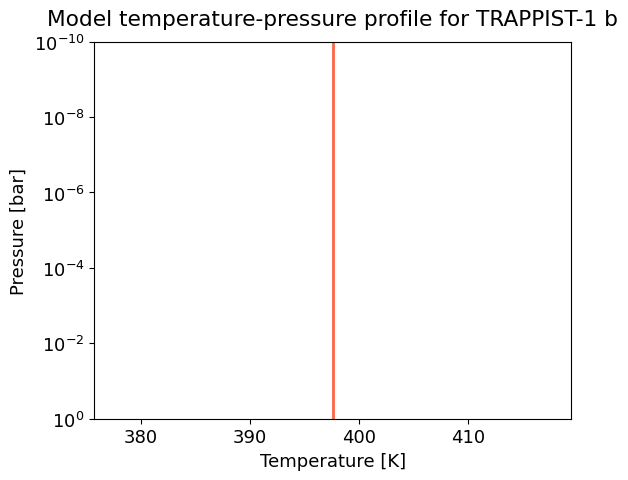

In [3]:
# Molecules to include in the model and their volume mixing ratios (abundances)
molecules = {
            'H2': 0.98,
            'He': 0.01,
            # 'H2O': 0.009
            # 'CO2': 0.009
            # 'CH4': 0.99999999
            'CH4': 0.009,
            }  # should add up to < 1

# Pressure
limP = [-10, 0]  # log10 of pressure at top-of-atmosphere and at surface/R_pl (unit: bar)

# Clouds
cloud = None  # pressure where opaque cloud deck is added to the absorption opacity (unit: bar), or None for no clouds

# Dissociation
dissociation = True  # allow for molecules to break up in the atmosphere

# Opacity parameters
log_kappa_IR = np.log10(0.01)  # log10 of the infrared opacity (unit: cm^2/s)
log_gamma = np.log10(0.4)  # log10 of the ratio between the optical and infrared opacity

# Temperature
T_int = 200.  # interior temperature of the planet (gas giants)
T_eq = 397.6  # equilibrium temperature of T-1 b
# T_eq = 2781.70  # equilibrium temperature of WASP-33 b
# T_eq = 1500  # equilibrium temperature of WASP-127 b

# Assume an isotherm?
isotherm = True

# Wavelength range of the model
wl_range = [0.95, 2.35]  # wavelength range of SPIRou (unit: micrometers)
# wl_range = [0.95, 1.8]  # wavelength range of NIRPS (unit: micrometers)

# Resolution of the model
instr_res = 75000  # resolution of SPIRou
# instr_res = 80000  # resolution of NIRPS high-efficiency mode

# Type of observation (how is this planet going to be observed?)
kind_trans = 'transmission'  # transmission or emission

#-------------------------------------------------------------#

# Names of the linelists that will be fetched by petitRADTRANS
mols_linelists = {
        'H2O': 'H2O_main_iso',
        'CO': 'CO_all_iso',
        'CO2': 'CO2_main_iso',
        'FeH': 'FeH_main_iso',
        'C2H2': 'C2H2_main_iso',
        'CH4': 'CH4_main_iso',
        'HCN': 'HCN_main_iso',
        'NH3': 'NH3_main_iso',
        'TiO': 'TiO_all_iso',
        'SiO': 'SiO_main_iso',
        'VO': 'VO',
        'OH': 'OH',
        'Na': 'Na',
        'K': 'K',
        'H-': 'H-',
        'H': 'H',
        'e-': 'e-',
        'Al': 'Al',
        'B': 'B',
        'Be': 'Be',
        'Ca': 'Ca',
        'CaII': 'Ca+',
        'Cr': 'Cr',
        'Fe': 'Fe',
        'FeII': 'Fe+',
        'Li': 'Li',
        'Mg': 'Mg',
        'MgII': 'Mg+',
        'N': 'N',
        'Si': 'Si',
        'Ti': 'Ti',
        'V': 'V',
        'VII': 'V+',
        'Y': 'Y',
                 }

# Species required by the model to compute properly
special_species = {"H", "H2", "H-", "He", "e-"}
special_abundances = {key: molecules.pop(key) for key in special_species if key in molecules} # extract these species to add them in later

# Generate the atmosphere
atmos_high, pressures = prt.gen_atm_all([mols_linelists[key] for key in molecules],
                                        continuum_opacities=['H-'],  # continuum absorber species
                                        limP=limP,
                                        n_pts=50,  # number of pressure values used to compute the atmosphere
                                        mode='lbl',  # high resolution mode with line-by-line treatment; for low-resolution mode, use 'c-k'
                                        lbl_opacity_sampling=4,  # samples one of every nth point of the opacities
                                        wl_range=wl_range)

gravity = planet_obj.gp.cgs.value  # planetary surface gravity (unit: cm/s^2)

# Generate the temperature-pressure profile
if isotherm:
    temperatures_day = np.full(len(pressures), T_eq)  # constant temperature throughout the atmosphere
else:
    temperatures_day = guillot_global(pressures, 10**log_kappa_IR, 10**log_gamma, gravity, T_int, T_eq)  # Guillot profile

# Plot it
plt.figure(figsize=(6,5))
plt.plot(temperatures_day, pressures, linewidth=2, color='tomato')

plt.xlabel("Temperature [K]")
plt.ylabel("Pressure [bar]")
plt.yscale("log")
plt.ylim(max(pressures), min(pressures))  # invert y axis to have outer space at the top
plt.title(f'Model temperature-pressure profile for {pl_name}', pad=12)
plt.tight_layout()
plt.show()


**Compute the abundances and the opacities at each wavelength.**

There are no parameters to play with in this cell. If an isotherm is assumed, then the abundances are also constant at all pressures.

The mean molecular weight of the atmosphere is 2.16 g/mol.


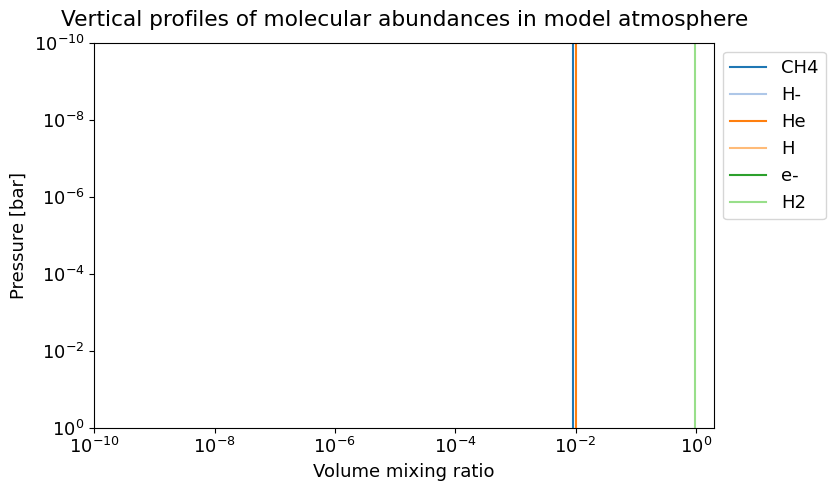

In [4]:
# Merge user-defined and required species, giving priority to user-specified abundances
molecules_full = molecules | {species: special_abundances.get(species, 1e-60) for species in special_species}

# Dictionary with the names of the linelists and the abundances
species_high = {mols_linelists[mol] if mol in mols_linelists else mol: abundance for mol, abundance in molecules_full.items()}

# Calculate mean molecular weight of the atmosphere
MMW = prt.calc_MMW3(species_high) * np.ones_like(pressures)
print(f"The mean molecular weight of the atmosphere is {MMW[0]:.2f} g/mol.")

if isotherm:
    # Calculate mass fractions for each molecule
    mass_frac = dict()

    for key in species_high:
        mass_frac[key] = prt.mass_fraction(key, species_high[key], MMW) * np.ones_like(pressures)
    
    # Calculate the transmission spectrum
    atmos_high.calc_transm(temperatures_day, mass_frac, gravity, MMW, R_pl=planet_obj.R_pl.cgs.value, P0_bar=limP[1])
    
    # Plot volume mixing ratios
    cmap = plt.cm.get_cmap('tab20')  # colormap
    plt.figure(figsize=(8,5))

    for i, key in enumerate(molecules_full.keys()):
        plt.plot(molecules_full[key] * np.ones_like(pressures), pressures, label=key, color=cmap.colors[i])

    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.xscale("log")
    plt.yscale("log")
    plt.xlim(1e-10, 2)
    plt.ylim(max(pressures), min(pressures))  # invert y axis to have outer space at the top
    plt.xlabel("Volume mixing ratio")
    plt.ylabel("Pressure [bar]")
    plt.title("Vertical profiles of molecular abundances in model atmosphere", pad=12)
    plt.show()
    
else:
    # Generate the model
    wlen, flux_lambda = prt.retrieval_model_plain(atmos_high,
                                                  species_high,
                                                  planet_obj,
                                                  pressures,
                                                  temperatures_day,
                                                  gravity,
                                                  limP[1],
                                                  cloud,
                                                  planet_obj.R_pl.cgs.value,
                                                  planet_obj.R_star.cgs.value,
                                                  dissociation=dissociation,
                                                  plot_abundance=True,  # plot the abundances
                                                  kind_trans=kind_trans)


**Resample and plot the model at the instrument resolution.**

There are no parameters to play with in this cell.

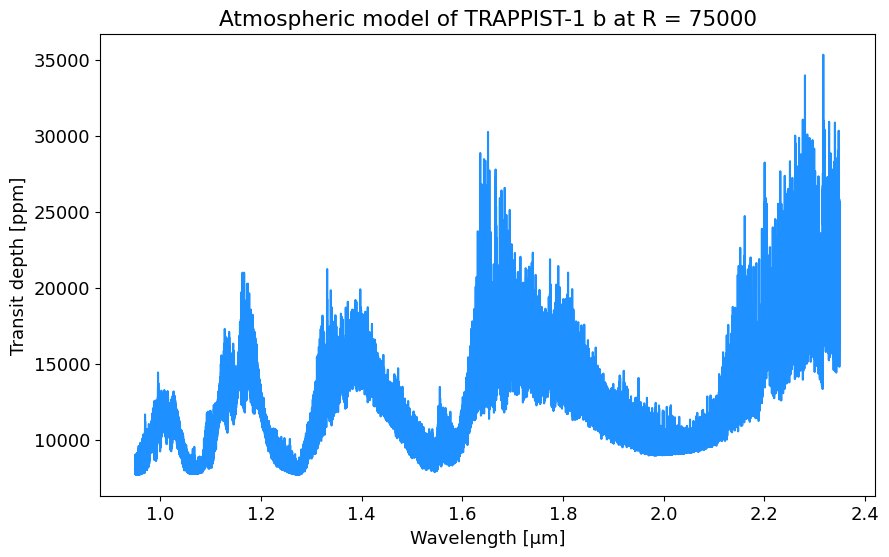

In [5]:
# Prepare model for the next steps of the analysis (cross-correlation, retrievals)
if isotherm:
    mod_tr_depth = (atmos_high.transm_rad / nc.r_earth / R_star.to(u.R_earth).value)**2  # convert transit radius to transit depth
    
    wave_mod, model_spec = prt.prepare_model(nc.c / atmos_high.freq / 1e-4,  # frequency grid converted to wavelength (unit: micrometers)
                                             mod_tr_depth,  # transit depth
                                             250000,  # full resolution of the model
                                             Raf=instr_res,  # resampled resolution
                                             rot_params=None)  # rotational kernel for convolution
    
else:
    wave_mod, model_spec = prt.prepare_model(wlen,  # model wavelengths (unit: micrometers)
                                             flux_lambda,  # transit radius (unit: Earth radii)
                                             250000,  # full resolution of the model
                                             Raf=instr_res,  # resampled resolution
                                             rot_params=None)  # rotational kernel for convolution

# Plot the model
plt.figure(figsize=(10,6))
plt.plot(wave_mod, model_spec * 1e6, color="dodgerblue")

plt.xlabel('Wavelength [µm]')
plt.ylabel('Transit depth [ppm]')
plt.title(f"Atmospheric model of {pl_name} at R = {instr_res}")
plt.show()

**Plot specific regions of the model if needed.**

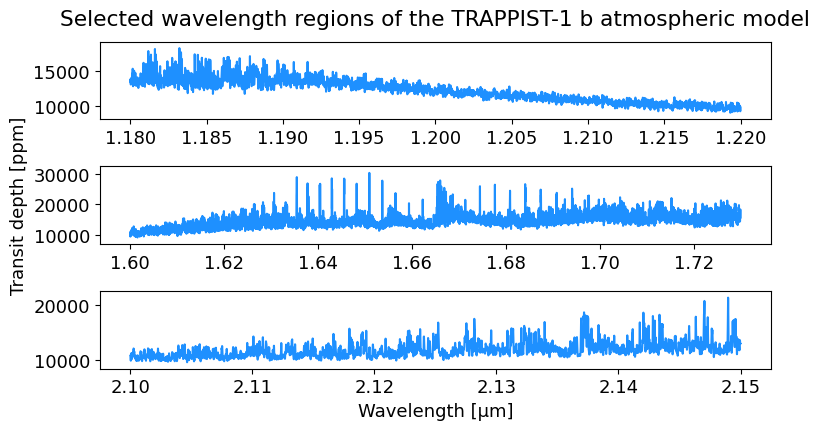

In [6]:
# List of wavelength ranges to zoom in on (in micrometers)
wv_ranges = [(1.18, 1.22),
             (1.6, 1.73),
             (2.1, 2.15)]

#-------------------------------------------------#

# Plot the wavelength regions on top of each other
fig, ax = plt.subplots(nrows=len(wv_ranges), ncols=1, figsize=(8, 1.5 * len(wv_ranges)))

for ax_i, wv_rng in zip(ax, wv_ranges):
    
    if wv_rng[0] < wave_mod[0] or wv_rng[1] > wave_mod[-1]:  # print a warning if one of the regions is outside of the wavelength grid
        print(f"The region {wv_rng[0]}-{wv_rng[1]} µm is partially or completely outside the wavelength range covered by the model.")
        continue
    
    # Select the wavelength indices within the current range
    mask = (wave_mod >= wv_rng[0]) & (wave_mod <= wv_rng[1])
    model_slice = model_spec[mask] * 1e6
    
    ax_i.plot(wave_mod[mask], model_slice, color="dodgerblue")
    
    # Set the ylims of each subplot
    ymin, ymax = np.nanmin(model_slice), np.nanmax(model_slice)
    margin = 0.1 * (ymax - ymin)
    ax_i.set_ylim(ymin - margin, ymax + margin)

ax[-1].set_xlabel('Wavelength [µm]')
ax[len(wv_ranges) // 2].set_ylabel('Transit depth [ppm]')
ax[0].set_title(f"Selected wavelength regions of the {pl_name} atmospheric model", pad=12)
plt.tight_layout()
plt.show()


## Store the model in a file

Save the model in your favourite directory. This model will then be fetched by different functions in the cross-correlation and retrievals notebooks.

In [7]:
# Directory where to store the model
save_model_directory = "/home/mathisb/Github/HRS_models/"

# Version (helps identifying the model files)
model_version = "v02"

#--------------------------------------------#

# Save the model
np.savez(save_model_directory + f"prt_model_{pl_name.replace(' ', '')}_{'_'.join(molecules.keys())}_{model_version}",
         wave_mod=wave_mod, model_spec=model_spec)
